In [13]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import os

In [14]:
df = pd.read_csv('../data/processed/steam_cleaned.csv')
print(f"Dados carregados: {df.shape}")

Dados carregados: (19371, 396)


In [15]:
features_cluster = [
    'price', 'average_playtime_hours', 'total_ratings', 'is_free', 'is_multiplayer'
]

df_cluster = df[features_cluster].dropna()
print(f"Usando {len(df_cluster)} amostras para clusterização.")

Usando 19371 amostras para clusterização.


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

Silhouette Score para k=2: 0.644
Silhouette Score para k=3: 0.695
Silhouette Score para k=4: 0.697
Silhouette Score para k=5: 0.701
Silhouette Score para k=6: 0.717


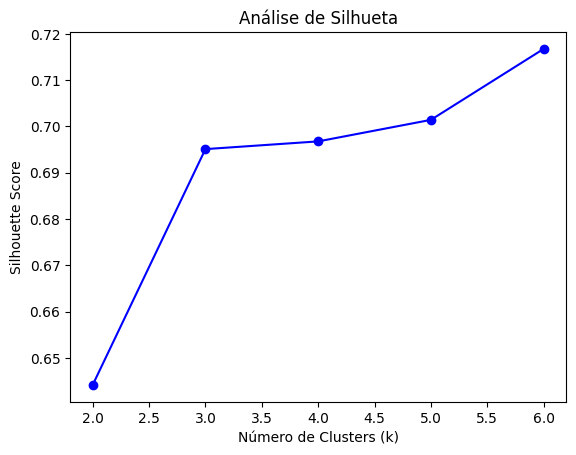

In [17]:
k_range = range(2, 7)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"Silhouette Score para k={k}: {score:.3f}")

plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Análise de Silhueta")
plt.show() 

In [18]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

In [19]:
cluster_analysis = df_cluster.groupby('cluster')[features_cluster].mean().sort_values('price', ascending=False)
print("\n--- Análise dos Clusters (Médias) ---")
print(cluster_analysis)


--- Análise dos Clusters (Médias) ---
             price  average_playtime_hours  total_ratings  is_free  \
cluster                                                              
1        10.569331                5.419185   3.538132e+03      0.0   
0         6.938709                1.846749   8.012207e+02      0.0   
2         0.000000              374.900000   3.046717e+06      1.0   
3         0.000000                9.198892   3.026066e+03      1.0   

         is_multiplayer  
cluster                  
1              0.995647  
0              0.000000  
2              1.000000  
3              0.304988  


In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_cluster['pca1'] = X_pca[:, 0]
df_cluster['pca2'] = X_pca[:, 1]
df_cluster['cluster_str'] = df_cluster['cluster'].astype(str)

In [21]:
fig = px.scatter(
    df_cluster.sample(n=10000, replace=True),
    x='pca1',
    y='pca2',
    color='cluster_str',
    title="Segmentação do Mercado da Steam (Visualização PCA)",
    hover_data=['price', 'average_playtime_hours', 'total_ratings']
)
fig.show()

In [22]:
os.makedirs('../models', exist_ok=True)

fig = px.scatter(
    df_cluster.sample(n=10000, replace=True), 
    x='pca1',
    y='pca2',
    color='cluster_str',
    title="Segmentação do Mercado da Steam (Visualização PCA)",
    hover_data=['price', 'average_playtime_hours', 'total_ratings']
)

fig.write_html("../models/pca_cluster_plot.html")
fig.show()

print("Gráfico PCA salvo em ../models/pca_cluster_plot.html")

Gráfico PCA salvo em ../models/pca_cluster_plot.html
